# DQN with ALE/Enduro-v5

This notebook loads [config.yaml](config.yaml) and trains the `QAgent` on `ALE/Enduro-v5` using the Gymnasium ALE API.

Enduro is a pixel-based Atari env: the observation is a `(210, 160, 3)` RGB frame and the action space is `Discrete(9)`. Following Mnih et al. (2015) — "Human-level control through deep reinforcement learning" — we apply the standard Atari preprocessing pipeline (max-pool over last two frames, grayscale, 84×84 resize, frame-skip 4, 4-frame stack) and learn from `(4, 84, 84)` uint8 stacks with a CNN Q-network.



## Imports

In [1]:
import sys, pathlib, yaml
from functools import partial
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Register ALE/* env ids with Gymnasium.
import ale_py
import gymnasium as gym
gym.register_envs(ale_py)

SRC = pathlib.Path.cwd().parents[1] / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from environments.base_env import make_environment
from agents.q_agent import QAgent
from training import dqn_training_loop
from analysis.low_rank.hankel_policy import hankel_rollout
from analysis.low_rank.rank import plot_matrix_spectra

## Reading the config file

In [2]:
with open("config.yaml") as f:
    cfg = yaml.safe_load(f)

dev = cfg["experiment"]["device"]
device = dev if (dev != "mps" or torch.backends.mps.is_available()) else "cpu"
seed = cfg["experiment"]["seed"]
torch.manual_seed(seed)
np.random.seed(seed)

cfg

{'experiment': {'name': 'dqn_enduro', 'seed': 52, 'device': 'mps'},
 'environment': {'name': 'ALE/Enduro-v5',
  'render_mode': None,
  'discrete_config': None,
  'normalise': {'action': {}, 'state': {}},
  'clip': {'action': False, 'state': {}},
  'atari': {'noop_max': 30,
   'frame_skip': 4,
   'screen_size': 84,
   'terminal_on_life_loss': False,
   'grayscale_obs': True,
   'grayscale_newaxis': False,
   'scale_obs': False,
   'frame_stack': 4}},
 'network': {'fc_hidden': 512},
 'agent': {'replay_buffer_capacity': 100000,
  'batch_size': 32,
  'nn_learning_rate': 0.0001,
  'eps_start': 1.0,
  'eps_min': 0.01,
  'decay_rate': 0.999982,
  'discount_factor': 0.99,
  'TD_LR': 0.0025,
  'buffer_util': 4},
 'training': {'no_episodes': 2000, 'target_network_update_steps': 2000},
 'analysis': {'ep_freq': 100,
  'methods': [{'name': 'hankel_rollout', 'kwargs': {'seed': 52}}]}}

## Creating the Environment

The `atari` block in the config triggers the Atari branch of `make_environment`, which wires `AtariPreprocessing` (frame-skip, grayscale, 84×84 resize, no-op reset) followed by `FrameStackObservation` (4 frames). The resulting observation_space is `Box(0, 255, (4, 84, 84), uint8)`.

In [3]:
env_cfg = cfg["environment"]
env = make_environment(
    env_cfg["name"],
    render_mode=env_cfg["render_mode"],
    discrete_config=env_cfg["discrete_config"],
    normalise=env_cfg["normalise"],
    clip=env_cfg["clip"],
    atari=env_cfg["atari"],
)
obs_shape = env.observation_space.shape   # (4, 84, 84)
n_actions = env.action_space.n             # 9 for Enduro
print("obs_shape:", obs_shape, "dtype:", env.observation_space.dtype, "n_actions:", n_actions)

A.L.E: Arcade Learning Environment (version 0.12.0+0706845)
[Powered by Stella]


obs_shape: (4, 84, 84) dtype: uint8 n_actions: 9


## CNN Q-network

Nature DQN architecture (Mnih et al. 2015), unchanged since it remains the standard baseline for Atari and is what every reproduction (OpenAI Baselines, Stable-Baselines3, CleanRL, Dopamine) uses out of the box for Enduro:

| Layer | Spec | Output |
|---|---|---|
| Conv1 | 4 → 32, kernel 8, stride 4 | 32×20×20 |
| Conv2 | 32 → 64, kernel 4, stride 2 | 64×9×9 |
| Conv3 | 64 → 64, kernel 3, stride 1 | 64×7×7 |
| FC1   | 3136 → 512 | 512 |
| FC2   | 512 → n_actions | Q-values |

The input is divided by 255 inside `forward` so the replay buffer can keep uint8/float32 frames without losing dynamic range.

In [4]:
class NatureCNN(nn.Module):
    """Maps a (C, 84, 84) frame stack to Q-values of shape (n_actions,)."""
    def __init__(self, in_channels, n_actions, fc_hidden=512):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),          nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),          nn.ReLU(),
            nn.Flatten(),
        )
        # 84 -> 20 -> 9 -> 7  => 64 * 7 * 7 = 3136
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, 84, 84)
            flat_dim = self.features(dummy).shape[1]
        self.head = nn.Sequential(
            nn.Linear(flat_dim, fc_hidden), nn.ReLU(),
            nn.Linear(fc_hidden, n_actions),
        )

    def forward(self, x):
        # x can be uint8 or float; rescale to [0,1] inside the network.
        x = x.float() / 255.0
        return self.head(self.features(x))

## Creating the Agent

In [ ]:
a = cfg["agent"]
nn_extra_kwargs = {
    "in_channels": obs_shape[0],
    "n_actions": n_actions,
    "fc_hidden": cfg["network"]["fc_hidden"],
}
agent = QAgent(
    replay_buffer_capacity=a["replay_buffer_capacity"],
    q_network=NatureCNN,
    batch_size=a["batch_size"],
    nn_learning_rate=a["nn_learning_rate"],
    nn_extra_kwargs=nn_extra_kwargs,
    env=env,
    eps_start=a["eps_start"],
    eps_min=a["eps_min"],
    decay_rate=a["decay_rate"],
    discount_factor=a["discount_factor"],
    device=device,
    TD_LR=a["TD_LR"],
    buffer_util=a["buffer_util"],
    gd_steps_ceil=a["gd_steps_ceil"],
)

## Analysis (Low Rank)

Only `hankel_rollout` is wired here — `q_matrix_dqn` discretises each observation dimension into bins, which is meaningless for `(4, 84, 84)` pixel stacks.

In [ ]:
analysis = cfg["analysis"]

analysis_methods = {
    "hankel_rollout": hankel_rollout,
}

analysis["methods"] = [
    (partial(analysis_methods[m["name"]], **m.get("kwargs", {})), m["outputs"])
    for m in analysis["methods"]
]
analysis

## Agent Training

Atari training is **slow**. Enduro episodes can run for thousands of env steps each (one in-game "day"), and the CNN forward/backward is far heavier than the MLP runs in CartPole/Acrobot. Expect the first signs of learning (mean reward starting to climb above 0) only after the buffer fills and a few hundred episodes have elapsed.

  0%|          | 0/2000 [00:00<?, ?it/s]

episode 0 avg_rewarg: 0.0
**************************** DEBUG INFO START **********************************
Episode 0 is complete with reward 0.0
Replay_buffer_length 3326
Epsilon for epsilon-greedy is 0.9418883472008392
**************************** DEBUG INFO END **********************************
Hankel Value Function


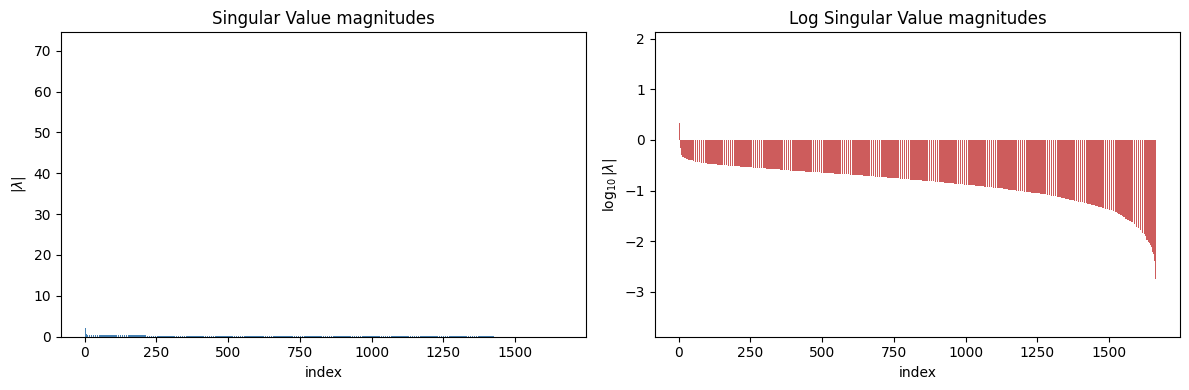

  0%|          | 2/2000 [00:24<5:47:33, 10.44s/it] 

**************************** DEBUG INFO START **********************************
Episode 1 is complete with reward 0.0
Replay_buffer_length 3327
Epsilon for epsilon-greedy is 0.8871376898268758
**************************** DEBUG INFO END **********************************


  0%|          | 3/2000 [00:37<6:25:04, 11.57s/it]

**************************** DEBUG INFO START **********************************
Episode 2 is complete with reward 0.0
Replay_buffer_length 6651
Epsilon for epsilon-greedy is 0.8356147342703024
**************************** DEBUG INFO END **********************************


  0%|          | 4/2000 [00:55<7:43:14, 13.93s/it]

...

episode 10 avg_rewarg: 0.0
**************************** DEBUG INFO START **********************************
Episode 10 is complete with reward 0.0
Replay_buffer_length 33233
Epsilon for epsilon-greedy is 0.5178508965645982
**************************** DEBUG INFO END **********************************


  1%|          | 12/2000 [03:26<13:45:56, 24.93s/it]

**************************** DEBUG INFO START **********************************
Episode 11 is complete with reward 0.0
Replay_buffer_length 36554
Epsilon for epsilon-greedy is 0.4878016256275614
**************************** DEBUG INFO END **********************************


  1%|          | 12/2000 [03:42<10:15:38, 18.58s/it]


KeyboardInterrupt: 

In [7]:
t = cfg["training"]
rewards = dqn_training_loop(
    agent, env,
    no_episodes=t["no_episodes"],
    target_network_update_steps=t["target_network_update_steps"],
    np_seed=seed,
    analysis_config=analysis,
    DEBUG=True,
)

## Training and Analysis Plots

In [ ]:
rewards = np.asarray(rewards, dtype=float)
plt.figure(figsize=(8, 4))
plt.plot(rewards, alpha=0.35, label="episode reward")
if len(rewards) >= 10:
    k = 10
    ma = np.convolve(rewards, np.ones(k) / k, mode="valid")
    plt.plot(range(k - 1, len(rewards)), ma, label=f"{k}-ep moving avg")
plt.xlabel("episode"); plt.ylabel("total reward"); plt.title("DQN on ALE/Enduro-v5")
plt.legend(); plt.show()

In [ ]:
for method, names in analysis["methods"]:
    results = method(agent=agent, env=env)
    if not isinstance(results, tuple):
        results = (results,)
    for matrix, name in zip(results, names):
        print(name)
        plot_matrix_spectra(matrix)